###### *131_6_lcm_defect_factor_dummy_answer.ipynb*

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams["font.family"] = "Meiryo"



In [25]:
df = pd.read_csv("dataset/lcm_defect_factor.csv")

In [26]:
df

,defect_id,site,model,occ_month,defect_qty,defect_factor
0,D001,SUS,J69P,2026-07,3,"部品,工程"
1,D002,SUS,310D,2026-07,2,設計
2,D003,WSE,36WA,2026-07,1,"部品,異物"
3,D004,GSE,3BVT,2026-08,4,"工程,作業ミス"
4,D005,META,J69P,2026-08,2,部品
5,D006,META,310D,2026-08,5,"設計,工程"
6,D007,MEAX,36WA,2026-09,1,異物
7,D008,MELAC,3BVT,2026-09,3,"部品,設計"
8,D009,SUS,36WA,2026-09,2,工程
9,D010,WSE,J69P,2026-10,4,"部品,作業ミス"


In [27]:
df["defect_factor"]

0        部品,工程
1           設計
2        部品,異物
3      工程,作業ミス
4           部品
5        設計,工程
6           異物
7        部品,設計
8           工程
9      部品,作業ミス
10       設計,異物
11    部品,工程,設計
Name: defect_factor, dtype: str

In [28]:
df_factor_dummy = df["defect_factor"].str.get_dummies(sep=",")


In [29]:
df_factor_dummy

,作業ミス,工程,異物,設計,部品
0,0,1,0,0,1
1,0,0,0,1,0
2,0,0,1,0,1
3,1,1,0,0,0
4,0,0,0,0,1
5,0,1,0,1,0
6,0,0,1,0,0
7,0,0,0,1,1
8,0,1,0,0,0
9,1,0,0,0,1


In [30]:
df = df.join(df_factor_dummy)

In [31]:
df

,defect_id,site,model,occ_month,defect_qty,defect_factor,作業ミス,工程,異物,設計,部品
0,D001,SUS,J69P,2026-07,3,"部品,工程",0,1,0,0,1
1,D002,SUS,310D,2026-07,2,設計,0,0,0,1,0
2,D003,WSE,36WA,2026-07,1,"部品,異物",0,0,1,0,1
3,D004,GSE,3BVT,2026-08,4,"工程,作業ミス",1,1,0,0,0
4,D005,META,J69P,2026-08,2,部品,0,0,0,0,1
5,D006,META,310D,2026-08,5,"設計,工程",0,1,0,1,0
6,D007,MEAX,36WA,2026-09,1,異物,0,0,1,0,0
7,D008,MELAC,3BVT,2026-09,3,"部品,設計",0,0,0,1,1
8,D009,SUS,36WA,2026-09,2,工程,0,1,0,0,0
9,D010,WSE,J69P,2026-10,4,"部品,作業ミス",1,0,0,0,1


In [32]:
factor_cols = df_factor_dummy.columns.tolist()

In [33]:
factor_cols

['作業ミス', '工程', '異物', '設計', '部品']

In [34]:
df

,defect_id,site,model,occ_month,defect_qty,defect_factor,作業ミス,工程,異物,設計,部品
0,D001,SUS,J69P,2026-07,3,"部品,工程",0,1,0,0,1
1,D002,SUS,310D,2026-07,2,設計,0,0,0,1,0
2,D003,WSE,36WA,2026-07,1,"部品,異物",0,0,1,0,1
3,D004,GSE,3BVT,2026-08,4,"工程,作業ミス",1,1,0,0,0
4,D005,META,J69P,2026-08,2,部品,0,0,0,0,1
5,D006,META,310D,2026-08,5,"設計,工程",0,1,0,1,0
6,D007,MEAX,36WA,2026-09,1,異物,0,0,1,0,0
7,D008,MELAC,3BVT,2026-09,3,"部品,設計",0,0,0,1,1
8,D009,SUS,36WA,2026-09,2,工程,0,1,0,0,0
9,D010,WSE,J69P,2026-10,4,"部品,作業ミス",1,0,0,0,1


In [35]:
df_factor_count = df[factor_cols].sum().reset_index()

In [36]:
df_factor_count

,index,0
0,作業ミス,2
1,工程,5
2,異物,3
3,設計,5
4,部品,6


In [37]:
df_factor_count.columns = ["factor", "count"]

In [38]:
df_factor_count

,factor,count
0,作業ミス,2
1,工程,5
2,異物,3
3,設計,5
4,部品,6


In [39]:
df_factor_count = df_factor_count.sort_values(
    "count",
    ascending=False,
).reset_index(drop=True)

In [40]:
df_factor_count

,factor,count
0,部品,6
1,設計,5
2,工程,5
3,異物,3
4,作業ミス,2


In [41]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

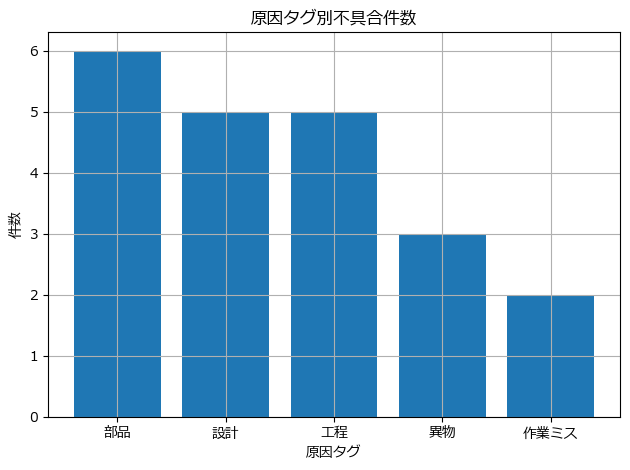

In [49]:
plt.bar(
    df_factor_count["factor"],
    df_factor_count["count"],
)

plt.title("原因タグ別不具合件数")
plt.xlabel("原因タグ")
plt.ylabel("件数")
plt.grid(axis="y")
plt.grid(axis="x")

plt.tight_layout()
plt.show()

In [50]:
df_site_part_count = df.groupby(
    "site",
    as_index=False,
)["部品"].sum()

In [51]:
df_site_part_count

,site,部品
0,GSE,0
1,MEAX,0
2,MELAC,2
3,META,1
4,SUS,1
5,WSE,2


In [52]:
df_site_part_count = df_site_part_count.rename(
    columns={
        "部品": "part_factor_count",
    }
)

In [53]:
df_site_part_count

,site,part_factor_count
0,GSE,0
1,MEAX,0
2,MELAC,2
3,META,1
4,SUS,1
5,WSE,2


In [54]:
df_month_process_count = df.groupby(
    "occ_month",
    as_index=False,
)["工程"].sum()

In [55]:
df_month_process_count

,occ_month,工程
0,2026-07,1
1,2026-08,2
2,2026-09,1
3,2026-10,1


In [56]:
df_month_process_count = df_month_process_count.rename(
    columns={
        "工程": "process_factor_count",
    }
)

In [57]:
df_month_process_count

,occ_month,process_factor_count
0,2026-07,1
1,2026-08,2
2,2026-09,1
3,2026-10,1


In [58]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

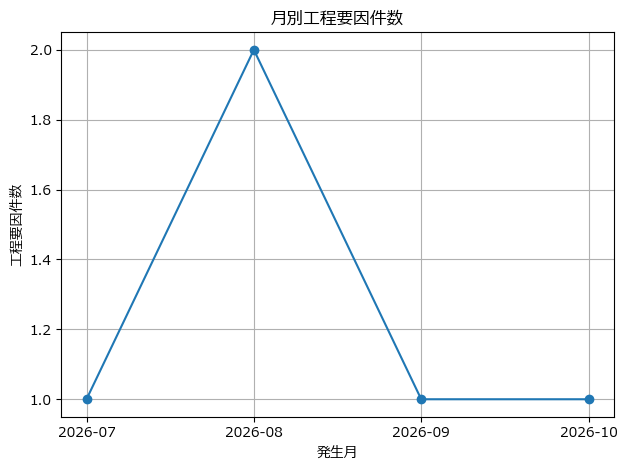

In [66]:
plt.plot(
    df_month_process_count["occ_month"],
    df_month_process_count["process_factor_count"],
    marker="o",
)

plt.title("月別工程要因件数")
plt.xlabel("発生月")
plt.ylabel("工程要因件数")
plt.grid(True)

plt.tight_layout()
plt.show()